## Importando as Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## Leitura e Validação dos Dados

In [2]:
# Fazendo a Leitura da Base de dados tratado
dados = pd.read_csv("../data/co2_clean.csv", index_col=0, parse_dates=True)
dados.head()

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [3]:
# Fazendo uma validação rápida

print(f"Classe do Index -> {type(dados.index)}")
print(f"\nShape -> {dados.shape}")

print(f"\nValores Ausentes:\n{dados.isna().sum()}")

print(f"\nOrdenado -> {dados.index.is_monotonic_increasing}")
print(f"Frequência -> {pd.infer_freq(dados.index)}")

print(
    f"\nPeríodo -> "
    f"{dados.index.min().date()} até {dados.index.max().date()}"
)

Classe do Index -> <class 'pandas.DatetimeIndex'>

Shape -> (2284, 1)

Valores Ausentes:
co2    0
dtype: int64

Ordenado -> True
Frequência -> W-SAT

Período -> 1958-03-29 até 2001-12-29


## Divisão Dados da Modelagem e Teste Final

In [4]:
semanas = 52

dados_modelagem = dados.iloc[:-semanas].copy()
teste_final = dados.iloc[-semanas:].copy()

Dados Modelagem -> 1958-03-29 até 2000-12-30
Dados Teste Final -> 2001-01-06 até 2001-12-29


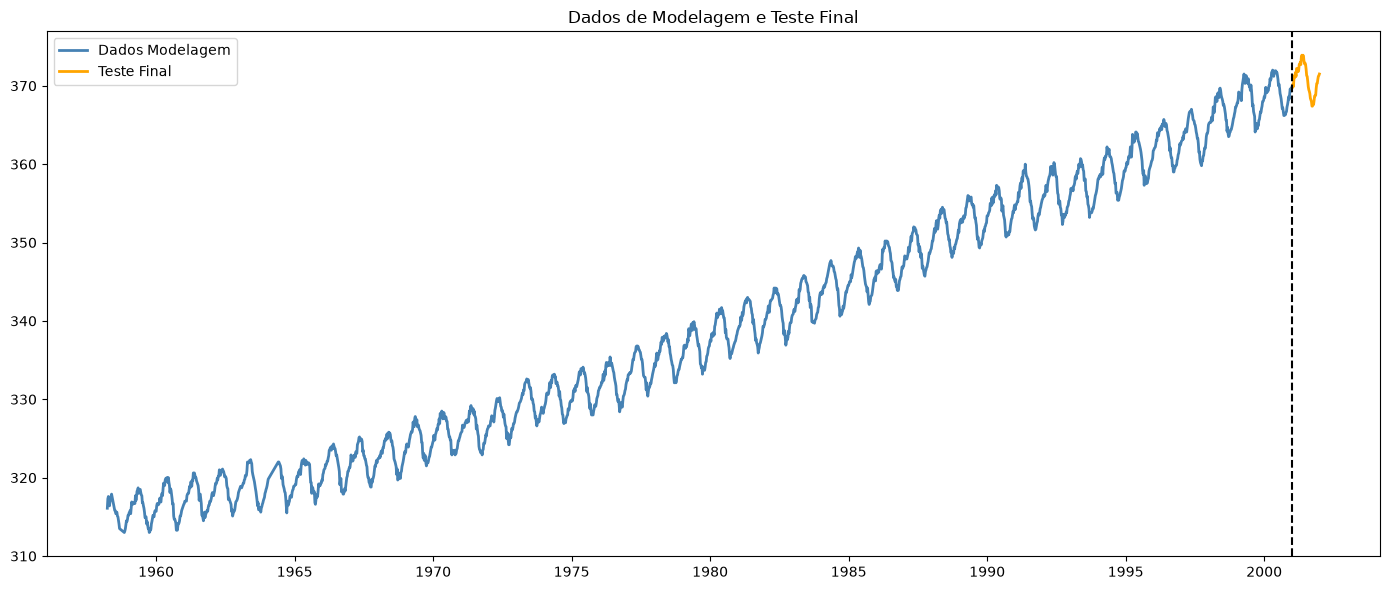

In [5]:
print(f"Dados Modelagem -> {dados_modelagem.index.min().date()} até {dados_modelagem.index.max().date()}")
print(f"Dados Teste Final -> {teste_final.index.min().date()} até {teste_final.index.max().date()}")

plt.figure(figsize=(14,6))
plt.plot(dados_modelagem.index, dados_modelagem.values, color='steelblue', linewidth=2.0, label='Dados Modelagem')
plt.plot(teste_final.index, teste_final.values, color='orange', linewidth=2.0, label='Teste Final')
plt.axvline(teste_final.index[0], color='black', linestyle='--')
plt.legend()
plt.title('Dados de Modelagem e Teste Final')
plt.tight_layout()
plt.show()

## Função para calcular métricas

In [6]:
def calcular_metricas(y_real, y_previsto):
    mae = mean_absolute_error(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto))
    mape = np.mean(np.abs((y_real - y_previsto) / y_real)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

# Modelos Estatísticos

## Modelo 1 - Holt-Winters

In [7]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=52
)

resultados_hw = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(dados_modelagem), start=1):

    treino = dados_modelagem.iloc[train_idx]['co2']
    validacao = dados_modelagem.iloc[val_idx]['co2']

    modelo = ExponentialSmoothing(
        treino,
        trend='add',
        seasonal='add',
        seasonal_periods=52
    ).fit()

    previsoes = modelo.forecast(steps=len(validacao))

    metricas = calcular_metricas(validacao, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Holt-Winters"

    resultados_hw.append(metricas)

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fr

## Modelo 2 - SARIMAX

In [8]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=52
)

resultados_sarimax = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(dados_modelagem), start=1):

    treino = dados_modelagem.iloc[train_idx]['co2']
    validacao = dados_modelagem.iloc[val_idx]['co2']

    modelo = SARIMAX(
        treino,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 52)
    ).fit()

    previsoes = modelo.forecast(steps=len(validacao))

    metricas = calcular_metricas(validacao, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "SARIMAX"

    resultados_sarimax.append(metricas)

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fr

In [9]:
resultados_hw = pd.DataFrame(resultados_hw)
resultados_sarimax = pd.DataFrame(resultados_sarimax)

resultados = pd.concat([resultados_hw, resultados_sarimax], ignore_index=True)

comparacao = (resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]))

comparacao

MAE                RMSE                MAPE          
                  mean       std      mean       std      mean       std
Modelo                                                                  
Holt-Winters  0.763999  0.332000  0.982502  0.417397  0.208729  0.090953
SARIMAX       0.503870  0.271599  0.621755  0.296449  0.137619  0.074086

# Modelos Machine Learning

## Preparação dos dados ML

In [10]:
df_ml = dados.copy()

# Lags
df_ml["lag_1"] = df_ml["co2"].shift(1)
df_ml["lag_2"] = df_ml["co2"].shift(2)
df_ml["lag_4"] = df_ml["co2"].shift(4)
df_ml["lag_13"] = df_ml["co2"].shift(13)
df_ml["lag_26"] = df_ml["co2"].shift(26)
df_ml["lag_52"] = df_ml["co2"].shift(52)

# Médias móveis
df_ml["rolling_mean_4"] = (df_ml["co2"].shift(1).rolling(4).mean())

df_ml["rolling_mean_13"] = (df_ml["co2"].shift(1).rolling(13).mean())

df_ml["rolling_mean_52"] = (df_ml["co2"].shift(1).rolling(52).mean())

# Sazonalidade
df_ml["week_of_year"] = (df_ml.index.isocalendar().week.astype(int))

df_ml["week_sin"] = np.sin(2 * np.pi * df_ml["week_of_year"] / 52)

df_ml["week_cos"] = np.cos(2 * np.pi * df_ml["week_of_year"] / 52)

df_ml.drop(columns="week_of_year", inplace=True)

# Remove observações sem histórico suficiente
df_ml = df_ml.dropna()

In [11]:
df_ml.head()

,co2,lag_1,lag_2,lag_4,lag_13,lag_26,lag_52,rolling_mean_4,rolling_mean_13,rolling_mean_52,week_sin,week_cos
1959-03-28,316.7,316.7,316.75,316.60,315.2,313.333333,316.1,316.7125,316.092308,315.413462,1.000000,-1.608123e-16
1959-04-04,317.7,316.7,316.70,316.80,315.2,313.277778,317.3,316.7375,316.207692,315.425000,0.992709,-1.205367e-01
1959-04-11,317.1,317.7,316.70,316.75,315.5,313.222222,317.6,316.9625,316.400000,315.432692,0.970942,-2.393157e-01
1959-04-18,317.6,317.1,317.70,316.70,315.6,313.166667,317.5,317.0500,316.523077,315.423077,0.935016,-3.546049e-01
1959-04-25,318.3,317.6,317.10,316.70,315.8,313.111111,316.4,317.2750,316.676923,315.425000,0.885456,-4.647232e-01


## Preparação dos Dados - Modelagem e Teste Final

In [12]:
data_inicio_teste = teste_final.index.min()
print(data_inicio_teste)

2001-01-06 00:00:00


In [13]:
dados_ml_modelagem = df_ml.iloc[df_ml.index < data_inicio_teste].copy()

teste_ml_final = df_ml.iloc[df_ml.index > data_inicio_teste].copy()

print(f"Dados Ml Modelagem -> {dados_ml_modelagem.index.min().date()} até {dados_ml_modelagem.index.max().date()}")
print(f"Teste ML Final -> {teste_ml_final.index.min().date()} até {teste_ml_final.index.max().date()}")

Dados Ml Modelagem -> 1959-03-28 até 2000-12-30
Teste ML Final -> 2001-01-13 até 2001-12-29


In [14]:
FEATURES = ['lag_1','lag_2','lag_4','lag_13','lag_26','lag_52','rolling_mean_4','rolling_mean_13','rolling_mean_52','week_sin','week_cos']

X_modelagem = dados_ml_modelagem[FEATURES]
y_modelagem = dados_ml_modelagem["co2"]

X_teste_final = teste_ml_final[FEATURES]
y_teste_final = teste_ml_final["co2"]

## Modelo 3 - Random Forest

In [15]:
resultados_rf = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem)):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=5,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas['Fold'] = fold
    metricas['Modelo'] = 'Random Forest'

    resultados_rf.append(metricas)

In [16]:
resultados_xgb = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem)):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas['Fold'] = fold
    metricas['Modelo'] = 'XGBoost'

    resultados_xgb.append(metricas)

### Comparando os Modelos utilizados

In [17]:
resultados_rf = pd.DataFrame(resultados_rf)
resultados_xgb = pd.DataFrame(resultados_xgb)

resultados = pd.concat([resultados_hw, resultados_sarimax, resultados_rf, resultados_xgb], ignore_index=True)

comparacao = (resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3))

comparacao

MAE          RMSE          MAPE       
                mean    std   mean    std   mean    std
Modelo                                                 
Holt-Winters   0.764  0.332  0.983  0.417  0.209  0.091
Random Forest  1.109  0.414  1.441  0.483  0.302  0.112
SARIMAX        0.504  0.272  0.622  0.296  0.138  0.074
XGBoost        0.924  0.295  1.155  0.363  0.252  0.080

## Fazendo o tunning dos modelos com RandomSearch

In [18]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

parametros_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 7],
    "min_samples_leaf": [1, 2, 4]
}

busca_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=parametros_rf,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca_rf.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparãmetros : {busca_rf.best_params_}")
print(f"\n Melhor MAE médio: {-busca_rf.best_score_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores Hiperparãmetros : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

 Melhor MAE médio: 0.7724483956936197


In [19]:
modelo_xgb = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    random_state=42,
    n_jobs=-1
)

parametros_xgb = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.05, 0.1, 1],
    "max_depth": [3, 5 , 10],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0]
}

busca_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=parametros_xgb,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca_xgb.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparãmetros : {busca_xgb.best_params_}")
print(f"\n Melhor MAE médio: {-busca_xgb.best_score_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores Hiperparãmetros : {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

 Melhor MAE médio: 0.8270654296875012


## Verificando os Modelos Tunning (walk-forward)

In [20]:
resultados_rf_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = RandomForestRegressor(
        **busca_rf.best_params_,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Random Forest Tuned"

    resultados_rf_tuned.append(metricas)

In [21]:
resultados_xgb_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(
        **busca_xgb.best_params_,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost Tuned"

    resultados_xgb_tuned.append(metricas)

In [30]:
resultados_rf_tuned = pd.DataFrame(resultados_rf_tuned)
resultados_xgb_tuned = pd.DataFrame(resultados_xgb_tuned)

resultados = pd.concat([resultados_hw, resultados_sarimax, resultados_rf_tuned, resultados_xgb_tuned], ignore_index=True)

comparacao = (resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3))

comparacao = comparacao.sort_values(
    by=("MAE", "mean"),
    ascending=True
)

comparacao

MAE          RMSE          MAPE       
                      mean    std   mean    std   mean    std
Modelo                                                       
SARIMAX              0.504  0.272  0.622  0.296  0.138  0.074
Holt-Winters         0.764  0.332  0.983  0.417  0.209  0.091
Random Forest Tuned  0.772  0.275  0.974  0.318  0.210  0.075
XGBoost Tuned        0.827  0.309  1.052  0.378  0.225  0.084

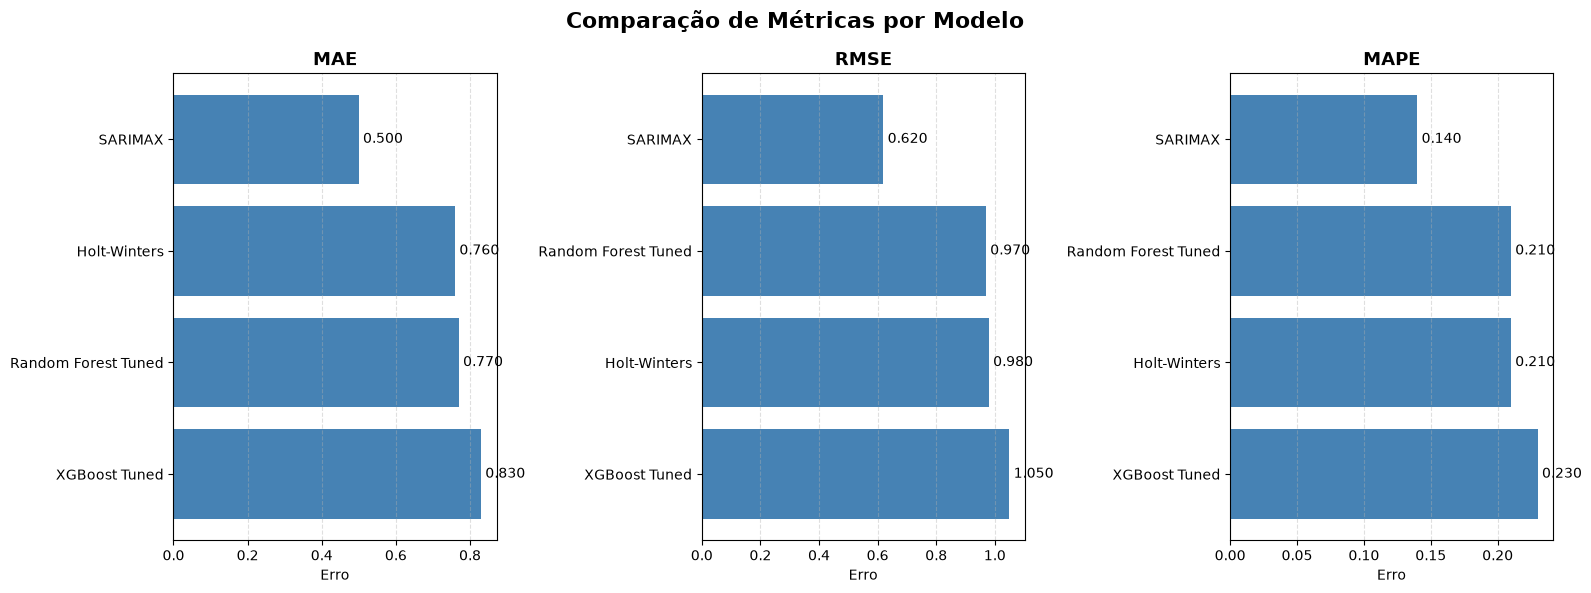

In [29]:
metricas_plot = pd.DataFrame({
    "MAE": comparacao[("MAE", "mean")],
    "RMSE": comparacao[("RMSE", "mean")],
    "MAPE": comparacao[("MAPE", "mean")]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = ["MAE", "RMSE", "MAPE"]

for ax, metrica in zip(axes, metricas):

    valores = metricas_plot[metrica].sort_values(ascending=False)

    bars = ax.barh(valores.index, valores.values, color="steelblue")

    ax.set_title(metrica, fontsize=13, fontweight="bold")

    ax.set_xlabel("Erro")

    ax.grid(axis="x", linestyle="--", alpha=0.4)

    ax.bar_label(bars, fmt="%.3f", padding=3)

fig.suptitle("Comparação de Métricas por Modelo", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()